In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vizdoom/doom_agent_gru.pth
/kaggle/input/vizdoom/archive/doom_e1m1.cfg
/kaggle/input/vizdoom/archive/DOOM1.WAD
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/.pre-commit-config.yaml
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/LICENSE
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/.gitignore
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/README.md
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/setup.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/tests/test_basic.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/__init__.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/envs/vizdoom_env_definitions.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/envs/vizdoomenv.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/envs/__init__.py
/kaggle/i

In [43]:
import sys
sys.path.append('/kaggle/input/vizdoom')  # donde quede el dataset


In [44]:
# Instalación de VizDoom
!pip install vizdoom --pre

In [45]:
# ============================
# CELDA 1: IMPORTS GENERALES
# ============================

import numpy as np          # Operaciones numéricas y manejo de matrices
import pandas as pd         # Manejo opcional de datos (logs, análisis simples)
import os                   # Leer archivos disponibles en /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import sys
sys.path.append('/kaggle/input/vizdoom')  # Añade VizDoom al path
from vizdoom import *                     # Librería principal del entorno Doom
import cv2                  # Procesamiento básico de imágenes
import matplotlib.pyplot as plt   # Gráficas para métricas y visualizaciones
import torch
import torch.nn as nn
import torch.optim as optim
# PyTorch: creación y entrenamiento del modelo neuronal
from collections import deque   # Estructura útil para buffers de frames
import imageio                 # Para generar GIFs de episodios
import seaborn as sns          # Estilo visual para gráficas
from IPython.display import Image   # Mostrar imágenes dentro del notebook
from vizdoom import *
from gym import spaces
from collections import deque

/kaggle/input/vizdoom/doom_agent_gru.pth
/kaggle/input/vizdoom/archive/doom_e1m1.cfg
/kaggle/input/vizdoom/archive/DOOM1.WAD
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/.pre-commit-config.yaml
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/LICENSE
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/.gitignore
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/README.md
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/setup.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/tests/test_basic.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/__init__.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/envs/vizdoom_env_definitions.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/envs/vizdoomenv.py
/kaggle/input/vizdoom/archive/vizdoomgym-master/vizdoomgym-master/vizdoomgym/envs/__init__.py
/kaggle/i

In [46]:
# CELDA 2: DoomFreedoomEnv 

class DoomFreedoomEnv:
    def __init__(self):
        self.game = DoomGame()
        self.game.set_doom_game_path("/kaggle/input/vizdoom/archive/freedoom-0.13.0/freedoom-0.13.0/freedoom2.wad")
        self.game.set_doom_scenario_path("/kaggle/input/vizdoom/archive/freedoom-0.13.0/freedoom-0.13.0/freedoom2.wad")
        self.game.set_doom_map("MAP01")

        self.game.set_window_visible(False)
        self.game.set_sound_enabled(False)
        self.game.set_screen_format(ScreenFormat.GRAY8)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)

        self.actions = [
            [1, 0, 0, 0, 0],
            [0, 1, 0, 0, 0],
            [0, 0, 1, 0, 0],
            [0, 0, 0, 1, 0],
            [0, 0, 0, 0, 1],
        ]

        self.buttons = [
            Button.MOVE_FORWARD, Button.MOVE_BACKWARD,
            Button.TURN_LEFT, Button.TURN_RIGHT, Button.ATTACK
        ]
        for b in self.buttons:
            self.game.add_available_button(b)

        for v in [
            GameVariable.POSITION_X, GameVariable.POSITION_Y,
            GameVariable.ANGLE, GameVariable.KILLCOUNT,
            GameVariable.HEALTH
        ]:
            self.game.add_available_game_variable(v)

        self.game.set_living_reward(-0.0001)
        self.game.set_episode_timeout(12000)
        self.game.set_death_penalty(1.0)
        self.game.set_mode(Mode.PLAYER)
        self.game.init()

        self.pos_history = deque(maxlen=10)
        self.prev_kills = 0
        self.prev_health = 0
        self.action_space_size = len(self.actions)

    def _get_frame(self):
        state = self.game.get_state()
        if state is None:
            return np.zeros((84, 84), dtype=np.uint8)
        return cv2.resize(state.screen_buffer, (84, 84)).astype(np.uint8)

    def reset(self):
        self.game.new_episode()
        state = self.game.get_state()
        v = state.game_variables

        self.pos_history.clear()
        self.pos_history.append((v[0], v[1]))
        self.prev_kills = v[3]
        self.prev_health = v[4]

        return self._get_frame()

    def step(self, action_id):
        _ = self.game.make_action(self.actions[action_id], 4)
        done = self.game.is_episode_finished()
        state = self.game.get_state()

        if state is None or state.game_variables[4] <= 0:
            return np.zeros((84, 84), dtype=np.uint8), -1.0, True

        x, y, angle, kills, health = state.game_variables
        reward = 0.0

        # 1. Recompensa por kill
        if kills > self.prev_kills:
            reward += 3.0

        # 2. Detector de atascos
        self.pos_history.append((x, y))
        if len(self.pos_history) == 10:
            x_old, y_old = self.pos_history[0]
            dist = np.sqrt((x - x_old)**2 + (y - y_old)**2)
            if action_id in [0, 1] and dist < 2.0:
                reward -= 0.02

        # 3. Retroceder (leve castigo)
        if action_id == 1:
            reward -= 0.0001

        # 4. Incentivo por avanzar
        if action_id == 0 and len(self.pos_history) > 1:
            lx, ly = self.pos_history[-2]
            step_dist = np.sqrt((x - lx)**2 + (y - ly)**2)
            if step_dist > 0.5:
                reward += 0.02

        # 5. Penalización por daño
        if health < self.prev_health:
            reward -= 0.03

        self.prev_kills = kills
        self.prev_health = health

        reward = np.clip(reward, -1.0, 3.0)
        return self._get_frame(), reward, done


Raw frame shape: (84, 84)


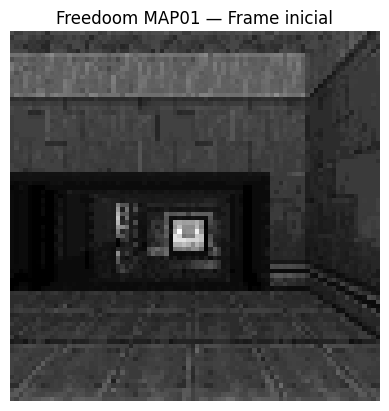

In [47]:
# CELDA 3:
# Crear una instancia del entorno personalizado de Doom
env = DoomFreedoomEnv()
# Reiniciar el entorno
frame = env.reset()
# Mostrar forma del frame procesado
print("Raw frame shape:", frame.shape)
# Graficar el primer frame del entorno (escala de grises)
plt.imshow(frame, cmap='gray')
plt.title("Freedoom MAP01 — Frame inicial")
plt.axis("off")
plt.show()

In [48]:
# CELDA 4: FrameStack (sin cambios)
class FrameStack:
    def __init__(self, k=4):
        # Cantidad de frames que se mantendrán apilados
        self.k = k
        # Buffer que guarda los últimos k frames
        self.frames = deque([], maxlen=k)

    def reset(self, frame):
        # Cuando empieza el episodio, se llenan los k frames con el mismo frame inicial
        self.frames = deque([frame]*self.k, maxlen=self.k)
        # Se apilan los frames en un solo tensor
        return np.stack(self.frames, axis=0)

    def step(self, frame):
         # Añade un nuevo frame y descarta el más antiguo automáticamente
        self.frames.append(frame)
        # Devuelve los últimos k frames apilados
        return np.stack(self.frames, axis=0)

In [49]:
# CELDA 5: ARQUITECTURA RECURRENTE (CNN + GRU)
# Detecta si hay GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Inicializador utilizado en todas las capas para mejorar estabilidad del entrenamiento
def init_layer(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class RecurrentActorCritic(nn.Module):
    def __init__(self, input_shape, action_dim):
        super().__init__()
        
        # 1. EXTRACTOR VISUAL (CNN)
        # Convierte los frames en un vector de características.
        self.conv = nn.Sequential(
            init_layer(nn.Conv2d(4, 32, 8, stride=4)), nn.ReLU(),
            init_layer(nn.Conv2d(32, 64, 4, stride=2)), nn.ReLU(),
            init_layer(nn.Conv2d(64, 64, 3, stride=1)), nn.ReLU()
        )

         # Calcular automáticamente el tamaño del vector final CNN
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            out = self.conv(dummy)
            self.flat_size = out.view(1, -1).shape[1]
            print(f"✔ CNN Output Size: {self.flat_size}")

        # 2. GRU — MÓDULO DE MEMORIA
        # Permite que el agente recuerde información temporal.
        self.gru_hidden_size = 512
        self.gru = nn.GRU(self.flat_size, self.gru_hidden_size, batch_first=True)
        
        # 3. SALIDAS DE LA RED (Actor y Crítico)
        # Actor → política (qué acción tomar)
        # Crítico → valor del estado
        self.actor = init_layer(nn.Linear(self.gru_hidden_size, action_dim), std=0.01)
        self.critic = init_layer(nn.Linear(self.gru_hidden_size, 1), std=1.0)
        
        
        # Módulo adicional para RND (feature extractor sin memoria)
        self.fc_rnd = nn.Linear(self.flat_size, 512)

    def forward(self, x, hidden=None):
        # Entrada esperada: (Batch, 4, 84, 84)
        
        # Normaliza si la imagen viene en escala 0–255
        if x.max() > 1.0: x = x.float() / 255.0
            
        # Paso por la CNN
        features = self.conv(x)
        features = features.view(features.size(0), -1) # Flatten (Batch, flat_size)
        
        # La GRU trabaja con una dimensión extra para secuencia
        features_seq = features.unsqueeze(1) 
        
        if hidden is None:
            # Si no hay memoria previa, se crea en cero
            hidden = torch.zeros(1, x.size(0), self.gru_hidden_size).to(device)
            
        # Paso por la GRU
        gru_out, new_hidden = self.gru(features_seq, hidden)
        
        # Tomamos la última salida para las capas finales
        gru_out_flat = gru_out[:, -1, :]
        # Actor → acciones   |   Critic → valor
        return self.actor(gru_out_flat), self.critic(gru_out_flat), new_hidden

    def get_features_for_rnd(self, x):
        # Obtiene características solo para RND (sin usar memoria)
        if x.max() > 1.0: x = x.float() / 255.0
        f = self.conv(x)
        f = f.view(f.size(0), -1)
        return torch.relu(self.fc_rnd(f))

In [50]:
# CELDA 6: RND OPTIMIZADO 
class RND(nn.Module):
    def __init__(self, feat_dim=512):
        super().__init__()
        
        # Dimensión interna reducida para simplificar el aprendizaje
        dim_h = 128 
        
        # TARGET NETWORK (Red fija que NO se entrena)
        # Esta red es completamente determinista y sirve como referencia.
        # Nunca debe cambiar durante el entrenamiento.
        self.target = nn.Sequential(
            init_layer(nn.Linear(feat_dim, dim_h)), 
            nn.LeakyReLU(), # LeakyReLU es mejor para evitar neuronas muertas en el target
            init_layer(nn.Linear(dim_h, dim_h))
        )
        
        # PREDICTOR NETWORK (Red que aprende a imitar al target)
        # Tiene más capas para darle mayor capacidad de aprendizaje.
        self.predictor = nn.Sequential(
            init_layer(nn.Linear(feat_dim, dim_h)), 
            nn.LeakyReLU(),
            init_layer(nn.Linear(dim_h, dim_h)), 
            nn.LeakyReLU(),
            init_layer(nn.Linear(dim_h, dim_h))
        )
        
        # El Target nunca se entrena, se congela completamente
        for p in self.target.parameters():
            p.requires_grad = False

    def forward(self, feat):
        # IMPORTANTE: feat viene de la CNN principal.
        # Debemos usar .detach() para que el entrenamiento del RND 
        # NO modifique los pesos de la CNN (Feature Extractor).
        # La CNN debe aprender a ver enemigos, no a facilitar la vida del RND.
        feat_in = feat.detach() 
        
        # Paso por ambas redes: predictor y target
        t = self.target(feat_in)
        p = self.predictor(feat_in)
        return p, t

In [51]:
# CELDA 7: PPO UPDATE 

def ppo_update(model, rnd, optM, optR, data, clip=0.2, epoch=4, batch=128):
    obs, acts, old_logp, returns, adv, hiddens = data

    obs = torch.tensor(obs, dtype=torch.float32).to(device)
    acts = torch.tensor(acts, dtype=torch.long).to(device)
    old_logp = torch.tensor(old_logp, dtype=torch.float32).to(device)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    adv = torch.tensor(adv, dtype=torch.float32).to(device)

    hiddens = torch.tensor(hiddens, dtype=torch.float32).to(device)
    hiddens = hiddens.permute(1, 0, 2).contiguous()

    adv = (adv - adv.mean()) / (adv.std() + 1e-5)

    dataset_size = len(obs)
    total_loss_val = 0

    for _ in range(epoch):
        idxs = np.random.permutation(dataset_size)

        for start in range(0, dataset_size, batch):
            b = idxs[start:start + batch]

            batch_obs = obs[b]
            batch_hidden = hiddens[:, b, :]

            logits, values, _ = model(batch_obs, batch_hidden)
            values = values.squeeze(-1)

            if torch.isnan(logits).any():
                continue

            dist = torch.distributions.Categorical(logits=logits)
            new_logp = dist.log_prob(acts[b])
            entropy = dist.entropy().mean()

            ratio = torch.exp(new_logp - old_logp[b])
            surr1 = ratio * adv[b]
            surr2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv[b]
            actor_loss = -torch.min(surr1, surr2).mean()

            value_unclipped = (values - returns[b]) ** 2
            value_clipped = (torch.clamp(values - returns[b], -clip, clip) + returns[b] - returns[b]) ** 2
            critic_loss = 0.5 * torch.max(value_unclipped, value_clipped).mean()

            loss = actor_loss + critic_loss - 0.01 * entropy

            optM.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.4)
            optM.step()

            total_loss_val += loss.item()

            # RND Update
            feat_rnd = model.get_features_for_rnd(batch_obs).detach()
            pred, targ = rnd(feat_rnd)
            rnd_loss = ((pred - targ)**2).mean()

            optR.zero_grad()
            rnd_loss.backward()
            torch.nn.utils.clip_grad_norm_(rnd.parameters(), 0.4)
            optR.step()

    return total_loss_val / max(1, (epoch * (dataset_size // batch)))


In [52]:
# CELDA DE CARGA DE CHECKPOINT 
import os
import torch

# 1. Configuración del nombre del archivo
CHECKPOINT_NAME = "/kaggle/input/vizdoom/doom_agent_gru.pth"


# 2. Instanciar la arquitectura (Cerebro vacío)
action_dim = env.action_space_size
input_shape = (4, 84, 84)

print("🔄 Construyendo arquitectura del Agente (GRU)...")
agent = RecurrentActorCritic(input_shape, action_dim).to(device)
rnd_model = RND(feat_dim=512).to(device)

# 3. Intento de cargar los pesos previamente guardados
# Si el archivo existe, se restauran los parámetros del agente.
if os.path.exists(CHECKPOINT_NAME):
    print(f"📂 Archivo encontrado: {CHECKPOINT_NAME}")
    try:
        # map_location permite cargar sin importar si antes era GPU y ahora es CPU
        checkpoint = torch.load(CHECKPOINT_NAME, map_location=device)
        
        # Se cargan los pesos dentro del modelo actual
        agent.load_state_dict(checkpoint)
        
        print("✅ ¡ÉXITO! Pesos cargados correctamente.")
        print("   El agente continuará con la inteligencia que tenía.")
        
    except Exception as e:
        # Si la arquitectura cambió, la carga fallará
        print(f"❌ ERROR CRÍTICO al cargar: {e}")
        print("   Esto suele pasar si cambiaste la arquitectura (ej. de CNN normal a GRU).")
        print("   ⚠ Se usará un agente NUEVO (desde cero).")
else:
    # Si no existe el archivo, se entrena desde cero
    print(f"⚠ No se encontró '{CHECKPOINT_NAME}'.")
    print("   🚀 Se iniciará un entrenamiento DESDE CERO.")

# 4. Activar modo entrenamiento en ambos modelos
agent.train()
rnd_model.train()

🔄 Construyendo arquitectura del Agente (GRU)...
✔ CNN Output Size: 3136
📂 Archivo encontrado: /kaggle/input/vizdoom/doom_agent_gru.pth
✅ ¡ÉXITO! Pesos cargados correctamente.
   El agente continuará con la inteligencia que tenía.


RND(
  (target): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (predictor): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
)

In [53]:
# CELDA 8: ENTRENAMIENTO FINAL (PPO + GRU + RND)

MAX_EPISODES = 500
BATCH_SIZE = 128
LR_ACTOR = 1e-4
LR_RND = 1e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
SAVE_INTERVAL = 100

if 'agent' in globals() and 'rnd_model' in globals():
    print("✅ Agente cargado: continuando entrenamiento...")
    if 'env' not in globals():
        env = DoomFreedoomEnv()
else:
    print("⚠ No se detectó agente, entrenando desde cero.")
    env = DoomFreedoomEnv()
    agent = RecurrentActorCritic((4, 84, 84), env.action_space_size).to(device)
    rnd_model = RND(feat_dim=512).to(device)

opt_agent = optim.Adam(agent.parameters(), lr=LR_ACTOR, eps=1e-5)
opt_rnd = optim.Adam(rnd_model.parameters(), lr=LR_RND, eps=1e-5)
sched_agent = optim.lr_scheduler.StepLR(opt_agent, step_size=500, gamma=0.92)

print("🧠 Iniciando entrenamiento...")

reward_history, kill_history, int_reward_history, loss_history = [], [], [], []

for ep in range(MAX_EPISODES):

    # Buffers
    b_obs, b_acts, b_logp = [], [], []
    b_rews, b_vals, b_int_rews = [], [], []
    b_hiddens = []

    frame = env.reset()
    state_stack = deque([frame]*4, maxlen=4)
    hidden = torch.zeros(1, 1, 512).to(device)

    ep_reward = 0
    ep_kills = 0
    ep_intr_total = 0
    done = False

    while not done:
        state_np = np.array(state_stack)
        state_t = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            logits, val, new_hidden = agent(state_t, hidden)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            logp = dist.log_prob(action)

            feat = agent.get_features_for_rnd(state_t)
            p, t = rnd_model(feat)
            int_reward = ((p - t)**2).mean().item()

        next_frame, reward, done = env.step(action.item())

        if reward >= 0.9:
            ep_kills += 1

        b_obs.append(state_np)
        b_acts.append(action.item())
        b_logp.append(logp.item())
        b_rews.append(reward)
        b_vals.append(val.item())
        b_int_rews.append(int_reward)
        b_hiddens.append(hidden.cpu().numpy().squeeze(0))

        hidden = new_hidden.detach()
        ep_reward += reward
        ep_intr_total += int_reward

        state_stack.append(next_frame)

    # POST EPISODIO
    b_obs, b_acts, b_logp = map(np.asarray, (b_obs, b_acts, b_logp))
    b_vals, b_rews, b_int_rews = map(np.asarray, (b_vals, b_rews, b_int_rews))
    b_hiddens = np.asarray(b_hiddens)

    # Normalización de curiosidad CORREGIDA
    eps = 1e-8
    b_int_rews = (b_int_rews - b_int_rews.mean()) / (b_int_rews.std() + eps)
    b_int_rews = b_int_rews * 0.02
    b_int_rews = np.clip(b_int_rews, -0.05, 0.05)

    total_rewards = b_rews + b_int_rews

    # GAE
    adv = np.zeros_like(total_rewards)
    returns = np.zeros_like(total_rewards)
    lastgaelam = 0

    for t in reversed(range(len(total_rewards))):
        if t == len(total_rewards)-1:
            nextnonterm = 0
            nextv = 0
        else:
            nextnonterm = 1
            nextv = b_vals[t+1]

        delta = total_rewards[t] + GAMMA * nextv * nextnonterm - b_vals[t]
        adv[t] = lastgaelam = delta + GAMMA * GAE_LAMBDA * nextnonterm * lastgaelam

    returns = adv + b_vals

    # PPO Update
    if len(b_obs) >= BATCH_SIZE:
        loss = ppo_update(
            agent, rnd_model, opt_agent, opt_rnd,
            (b_obs, b_acts, b_logp, returns, adv, b_hiddens),
            batch=BATCH_SIZE
        )
        loss_history.append(loss)
    else:
        loss = 0

    sched_agent.step()

    reward_history.append(ep_reward)
    kill_history.append(ep_kills)
    int_reward_history.append(ep_intr_total)

    if ep % 10 == 0:
        print(f"[EP {ep}] Rew:{ep_reward:.2f} Kills:{ep_kills} Loss:{loss:.4f} IntR:{ep_intr_total:.2f}")

    if ep > 0 and ep % SAVE_INTERVAL == 0:
        torch.save(agent.state_dict(), "doom_agent_gru.pth")
        print(f"💾 Guardado checkpoint en EP {ep}")

print("✅ Entrenamiento finalizado.")


✅ Agente cargado: continuando entrenamiento...
🧠 Iniciando entrenamiento...
[EP 0] Rew:8.52 Kills:0 Loss:-0.0541 IntR:135215.10
[EP 10] Rew:7.60 Kills:0 Loss:-0.0640 IntR:25242.64
[EP 20] Rew:8.10 Kills:0 Loss:-0.0591 IntR:21387.38
[EP 30] Rew:8.76 Kills:0 Loss:-0.0641 IntR:16571.32
[EP 40] Rew:9.00 Kills:0 Loss:-0.0467 IntR:13991.55
[EP 50] Rew:7.78 Kills:0 Loss:-0.0588 IntR:11560.23
[EP 60] Rew:10.41 Kills:0 Loss:-0.0573 IntR:10448.11
[EP 70] Rew:9.54 Kills:0 Loss:-0.0482 IntR:8810.25
[EP 80] Rew:6.14 Kills:0 Loss:-0.0422 IntR:8726.98
[EP 90] Rew:10.25 Kills:0 Loss:-0.0461 IntR:8081.87
[EP 100] Rew:15.05 Kills:0 Loss:-0.0537 IntR:7008.95
💾 Guardado checkpoint en EP 100
[EP 110] Rew:13.60 Kills:0 Loss:-0.0484 IntR:7261.54
[EP 120] Rew:-10.39 Kills:0 Loss:-0.0390 IntR:10220.67
[EP 130] Rew:5.38 Kills:0 Loss:-0.0457 IntR:6964.53
[EP 140] Rew:14.30 Kills:0 Loss:-0.0427 IntR:6704.97
[EP 150] Rew:14.43 Kills:0 Loss:-0.0386 IntR:6305.90
[EP 160] Rew:12.86 Kills:0 Loss:-0.0483 IntR:6624.53
[

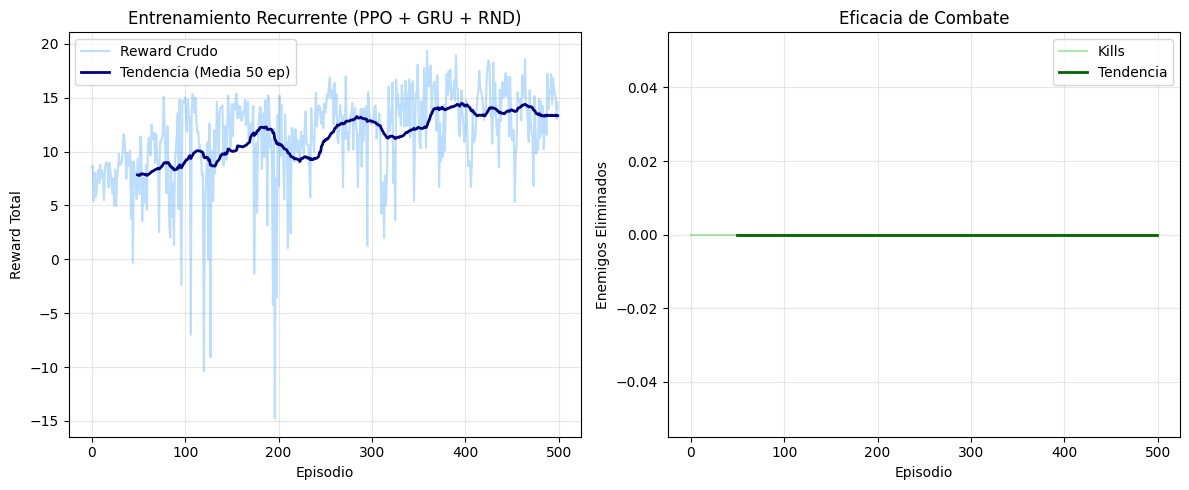

In [54]:
# CELDA 9: Visualización de Resultados (Versión GRU)
import matplotlib.pyplot as plt
import numpy as np

def plot_rewards(rewards, kills=None):
    plt.figure(figsize=(12, 5))
    
    # --- GRÁFICA 1: REWARDS ---
    plt.subplot(1, 2, 1)
    plt.plot(rewards, label='Reward Crudo', color='dodgerblue', alpha=0.3)
    
    if len(rewards) >= 50:
        # Media móvil más larga para ver tendencia en 5000 episodios
        moving_avg = np.convolve(rewards, np.ones(50)/50, mode='valid')
        plt.plot(range(49, len(rewards)), moving_avg, color='navy', linewidth=2, label='Tendencia (Media 50 ep)')
    
    plt.xlabel("Episodio")
    plt.ylabel("Reward Total")
    plt.title("Entrenamiento Recurrente (PPO + GRU + RND)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- GRÁFICA 2: KILLS ---
    if kills is not None and len(kills) > 0:
        plt.subplot(1, 2, 2)
        plt.plot(kills, label='Kills', color='limegreen', alpha=0.4)
        
        if len(kills) >= 50:
            avg_kills = np.convolve(kills, np.ones(50)/50, mode='valid')
            plt.plot(range(49, len(kills)), avg_kills, color='darkgreen', linewidth=2, label='Tendencia')
            
        plt.xlabel("Episodio")
        plt.ylabel("Enemigos Eliminados")
        plt.title("Eficacia de Combate")
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Detectar variables automáticamente
rewards_data = reward_history if 'reward_history' in globals() else []
kills_data = kill_history if 'kill_history' in globals() else []

if len(rewards_data) > 0:
    plot_rewards(rewards_data, kills_data)
else:
    print("⚠ No hay datos para graficar aún.")

In [55]:
# ============================================
# CELDA 10: EVALUACIÓN DEL AGENTE RECURRENTE (GRU)
# ============================================

import imageio
import matplotlib.pyplot as plt
from collections import deque

def evaluate_recurrent_agent(env, model, episodes=3, max_steps=2200,
                             stochastic=True, gif_name="eval_gru.gif"):
    """
    Evalúa un agente recurrente (GRU) sin afectar el entrenamiento.
    Genera un GIF del primer episodio.
    """
    print("🧠 Evaluando agente con memoria GRU...")
    model.eval()

    total_rewards = []
    frames_for_gif = []

    for ep in range(episodes):
        frame = env.reset()
        state_stack = deque([frame] * 4, maxlen=4)

        # Inicialización de memoria recurrente
        hidden = torch.zeros(1, 1, 512).to(device)

        done = False
        ep_reward = 0
        step = 0

        print(f"--- Episodio {ep+1}/{episodes} ---")

        # Guardamos el primer frame del primer episodio
        if ep == 0:
            frames_for_gif.append(frame)

        while not done and step < max_steps:
            step += 1

            # Convertimos el estado a tensor
            state_np = np.array(state_stack)
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                logits, _, new_hidden = model(x, hidden)

                # Actualizamos la memoria
                hidden = new_hidden.detach()

                # Acción estocástica (exploración) o greedy (explotación)
                if stochastic:
                    dist = torch.distributions.Categorical(logits=logits)
                    action = dist.sample().item()
                else:
                    action = torch.argmax(logits, dim=-1).item()

            # Avanzar entorno
            next_frame, reward, done = env.step(action)
            state_stack.append(next_frame)
            ep_reward += reward

            # Guardar frame para el GIF solo en el primer episodio
            if ep == 0:
                frames_for_gif.append(next_frame)

        print(f"   → Reward final: {ep_reward:.2f}")
        total_rewards.append(ep_reward)

    # ================================
    # GENERACIÓN DEL GIF
    # ================================
    if len(frames_for_gif) > 0:
        print(f"💾 Guardando GIF en: {gif_name}")

        # Asegura formato RGB para imageio
        rgb_frames = [np.stack([f]*3, axis=-1) for f in frames_for_gif]

        imageio.mimsave(gif_name, rgb_frames, fps=25)

    model.train()  # Regresamos al modo entrenamiento

    return total_rewards


# ---- EJECUCIÓN ----
if 'agent' in globals():
    evaluation_rewards = evaluate_recurrent_agent(env, agent, episodes=1, stochastic=True)
    print("Recompensas de evaluación:", evaluation_rewards)
else:
    print("⚠ Primero define 'agent' antes de evaluar.")


🧠 Evaluando agente con memoria GRU...
--- Episodio 1/1 ---
   → Reward final: 10.08
💾 Guardando GIF en: eval_gru.gif


/usr/local/lib/python3.11/dist-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Recompensas de evaluación: [10.081199999999903]


In [56]:
# CELDA 11: random_agent 
def random_agent(env, num_eval=100):
    rewards = []
    for _ in range(num_eval):
        frame = env.reset()
        done = False
        ep_r = 0
        while not done:
            # Selecciona una acción al azar entre las 5 disponibles
            act = np.random.choice(5)
            _, r, done = env.step(act)
            ep_r += r
        rewards.append(ep_r)
    return rewards

def make_random_gif(env, gif_name="random_agent.gif"):
    frame = env.reset()
    frames = []
    done = False
    while not done:
        act = np.random.choice(5)
        next_frame, _, done = env.step(act)
        frames.append(next_frame)
    # Convertimos GRAYSCALE → RGB para guardar como GIF
    rgb_frames = [np.stack([f]*3, -1) for f in frames]
    imageio.mimsave(gif_name, rgb_frames, fps=20)
    print(f"GIF random: {gif_name}")
    
# Ejecutar evaluación del agente aleatorio
random_rewards = random_agent(env)
# Generar GIF del comportamiento aleatorio
make_random_gif(env)

# COMPARACIÓN: PPO vs Random, últimos 100 episodios
min_len = min(100, len(rewards))
plt.figure(figsize=(12,6))
plt.plot(rewards[-min_len:], label="PPO")
plt.plot(random_rewards[-min_len:], label="Random")
plt.title("PPO vs Random (últ 100 eps)")
plt.legend()
plt.grid(True)
plt.show()

Image(filename="random_agent.gif")

GIF random: random_agent.gif


NameError: name 'rewards' is not defined